# Evaluación comparativa del método Chain-Ladder clásico y versiones robustas para estimar el IBNR bajo contaminación controlada

Este cuaderno presenta el experimento principal del trabajo. El objetivo es comparar el desempeño del método Chain-Ladder clásico frente a tres variantes robustas en la estimación del IBNR cuando los triángulos de desarrollo contienen valores atípicos controlados.

La validación previa del simulador se documenta en un cuaderno separado: `validacion_simulador_ibnr.ipynb`. En este archivo se parte de esa validación y se desarrolla el análisis central: definición de escenarios, ejecución Monte Carlo, cálculo de métricas, comparación entre métodos e interpretación de resultados.

## Estructura general del cuaderno

El desarrollo se organiza para seguir el orden del experimento final, sin mezclarlo con la prueba interna del simulador:

1. **Planteamiento del estudio.** Se presentan la pregunta, el objetivo y las hipótesis de trabajo.
2. **Diseño experimental.** Se fijan la dimensión del triángulo, los supuestos de simulación y la matriz de escenarios.
3. **Métodos de estimación.** Se definen el Chain-Ladder clásico y las variantes robustas que serán comparadas.
4. **Experimento Monte Carlo.** Se ejecutan las réplicas bajo los escenarios definidos.
5. **Evaluación de resultados.** Se calculan métricas, rankings y comparaciones pareadas frente al método clásico.
6. **Conclusiones.** Se conectan los resultados con las hipótesis y con la pregunta de investigación.

La prueba del simulador no se elimina del proyecto; queda separada para que funcione como soporte metodológico previo y no interrumpa la lectura del experimento principal.

## Planteamiento del estudio

**Pregunta de investigación.** ¿En qué medida la presencia de valores atípicos altera el desempeño del método Chain-Ladder clásico en la estimación del IBNR y bajo qué combinaciones de contaminación las variantes robustas ofrecen estimaciones más precisas y estables?

**Objetivo general.** Comparar el desempeño del método Chain-Ladder clásico y de tres variantes robustas en la estimación del IBNR, mediante simulación Monte Carlo de triángulos de desarrollo bajo escenarios controlados de contaminación, para establecer si los enfoques robustos ofrecen ventajas en precisión y estabilidad cuando la información observada contiene outliers.

**Hipótesis de trabajo.**

- H1. En escenarios contaminados, el error y la variabilidad del método Chain-Ladder clásico aumentan a medida que crecen la proporción y la magnitud de la contaminación, mientras que al menos una variante robusta mantiene un comportamiento relativamente más estable.

La hipótesis se evalúa al final del cuaderno mediante métricas de error, desviación estándar, rankings por escenario y comparaciones pareadas sobre las mismas réplicas simuladas.

## Fundamento teórico y criterio de diseño

La literatura actuarial establece que el Chain-Ladder clásico es altamente sensible a observaciones atípicas. Mack (1993) formaliza el marco estocástico del método y muestra cómo cuantificar el error de predicción. England y Verrall (2002) destacan que la principal ventaja de los modelos estocásticos de reserving es la disponibilidad de medidas explícitas de precisión. Verdonck et al. (2009) y Verdonck y Debruyne (2011) muestran, desde la perspectiva de robustez e influencia, que incluso una sola observación extrema puede desplazar de forma importante la reserva estimada. Más recientemente, Avanzi et al. (2024) profundizan en la sensibilidad posicional del reserving frente a outliers y documentan que las celdas cercanas a la frontera observada pueden ejercer una influencia particularmente alta.

A partir de ese marco, el diseño implementado adopta una lógica deliberadamente comparativa: el IBNR real se conoce por construcción, la contaminación se introduce únicamente sobre la región observable y los métodos compiten sobre los mismos triángulos simulados. Esta estructura produce comparaciones pareadas, reduce el ruido Monte Carlo en las diferencias entre métodos y permite una lectura más sólida de la evidencia empírica.

## Ruta metodológica del experimento principal

El experimento principal se desarrolla como una secuencia de pasos que conviene leer en orden:

1. Se fijan la dimensión del triángulo, la distribución de base y los parámetros del proceso generador.
2. Se construye la matriz de escenarios con base en la proporción, la magnitud y la ubicación de la contaminación.
3. Se simulan triángulos incrementales completos y se obtiene su versión acumulada.
4. Se define la región observada y se calcula el IBNR verdadero en la zona futura no observada.
5. Se introduce contaminación solo en la región observable del triángulo incremental.
6. Se estiman los factores de desarrollo y el IBNR con el método clásico y con las variantes robustas.
7. Se repite el procedimiento para todas las réplicas y todos los escenarios del diseño.
8. Se resumen los resultados con métricas de error, rankings por escenario y comparaciones pareadas frente al método clásico.

La validación del simulador corresponde a una etapa previa y separada. Su función es verificar que la simulación respeta los supuestos del estudio. Por esa razón se documenta en `validacion_simulador_ibnr.ipynb` y no dentro de los resultados finales.

## Entorno computacional y reproducibilidad

La implementación se apoya en librerías de uso estándar para simulación, análisis tabular y visualización:

- `numpy`: simulación aleatoria, álgebra matricial y operaciones vectorizadas.
- `pandas`: organización tabular de réplicas, escenarios y métricas.
- `matplotlib` y `seaborn`: visualización de resultados.
- `pathlib`: manejo portable de rutas del repositorio.

El código reutilizable se encuentra en `src/ibnr_project`. Este cuaderno concentra el experimento principal y la discusión de resultados, mientras que la validación del simulador queda documentada por separado. La semilla aleatoria se fija de forma explícita para garantizar reproducibilidad.

In [1]:
# Preparación de rutas del proyecto
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

OUTPUT_DIR = ROOT / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Librerías y funciones necesarias para el experimento principal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from ibnr_project.config import build_default_config, build_default_scenarios, clone_config
from ibnr_project.diagnostics import (
    build_link_ratio_count_table,
    compute_running_statistics,
    summarize_method_dominance,
)
from ibnr_project.evaluation import (
    compare_methods_to_baseline,
    compute_method_metrics,
    rank_methods_within_scenario,
)
from ibnr_project.experiment import build_global_summary, run_experiment
from ibnr_project.methods import estimate_ibnr_all_methods
from ibnr_project.simulation import observed_mask, simulate_single_triangle

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titleweight"] = "bold"

## Configuración experimental

El experimento se implementa sobre triángulos de dimensión `10 × 10`, donde las filas representan años de ocurrencia y las columnas periodos de desarrollo. Esta dimensión permite trabajar con un horizonte completo de diez años sin producir un costo computacional excesivo para las réplicas Monte Carlo.

Los montos incrementales se generan con esperanza `E[X_{i,j}] = μ_i d_j` y varianza `Var(X_{i,j}) = φ (μ_i d_j)^2`. El patrón acumulado se fija de forma exógena y de él se derivan las proporciones incrementales esperadas.

In [3]:
# Definición de parámetros base y escenarios del experimento
SEED = 20260503
config = build_default_config(random_seed=SEED, distribution="gamma")
scenarios = build_default_scenarios()
mask = observed_mask(config.n_periods)

scenario_df = pd.DataFrame([scenario.__dict__ for scenario in scenarios])
scenario_df

,name,proportion,magnitude,location
0,base_sin_contaminacion,0.0000,1.0000,none
1,p5_m2_random,0.0500,2.0000,random
2,p5_m2_early,0.0500,2.0000,early
3,p5_m2_late,0.0500,2.0000,late
4,p5_m5_random,0.0500,5.0000,random
5,p5_m5_early,0.0500,5.0000,early
6,p5_m5_late,0.0500,5.0000,late
7,p5_m10_random,0.0500,10.0000,random
8,p5_m10_early,0.0500,10.0000,early
9,p5_m10_late,0.0500,10.0000,late


La tabla anterior contiene la matriz completa de escenarios. El experimento combina tres dimensiones de contaminación:

- **Proporción de celdas contaminadas**: `0%`, `5%`, `10%` y `20%`.
- **Magnitud del outlier**: multiplicación por `1`, `2`, `5` y `10`. El factor `1` solo aparece en el escenario base, donde no hay contaminación efectiva.
- **Ubicación de la contaminación**:
  - `random`: selección aleatoria dentro de la región observable;
  - `early`: primer tercio de celdas observadas de cada fila;
  - `late`: último tercio de celdas observadas de cada fila.

De esta forma, el estudio no se limita a distinguir entre “con” y “sin” outliers, sino que explora cuánto cambia el desempeño del reserving cuando la contaminación es más frecuente, más intensa o aparece cerca de la frontera observada.

## Justificación de decisiones metodológicas

Las decisiones centrales del diseño se resumen a continuación para dejar explícito qué se hizo y cuál es su papel dentro del estudio.

In [4]:
# Resumen de las principales decisiones metodológicas del experimento
justification_df = pd.DataFrame(
    [
        {
            "decision": "Triángulos 10 × 10",
            "justificacion": "Es una dimensión clásica en reserving, suficiente para reproducir una zona observada y una zona futura relevantes sin volver innecesariamente pesado el experimento.",
            "papel_en_el_estudio": "Permite comparar métodos con una estructura triangular completa y con número decreciente de ratios por periodo.",
        },
        {
            "decision": "1000 réplicas en el caso base",
            "justificacion": "Se busca estabilizar métricas como RMSE, MAPE y desviación estándar sin perder viabilidad computacional.",
            "papel_en_el_estudio": "Sostiene la comparación Monte Carlo entre métodos y escenarios.",
        },
        {
            "decision": "Distribución Gamma como caso base",
            "justificacion": "Genera montos positivos y asimétricos, compatibles con pagos incrementales, y permite controlar media y dispersión de forma directa.",
            "papel_en_el_estudio": "Define el escenario principal del experimento.",
        },
        {
            "decision": "Sensibilidad Lognormal",
            "justificacion": "Permite revisar si los hallazgos cambian cuando la distribución subyacente tiene colas más pesadas.",
            "papel_en_el_estudio": "Evalúa la estabilidad de las conclusiones frente a un mecanismo alternativo de simulación.",
        },
        {
            "decision": "Contaminación positiva y multiplicativa",
            "justificacion": "Aísla el efecto de observaciones influyentes de gran magnitud sobre los factores de desarrollo.",
            "papel_en_el_estudio": "Permite medir cómo se distorsiona el IBNR cuando los datos observados contienen outliers.",
        },
        {
            "decision": "Proporciones 5 %, 10 % y 20 %",
            "justificacion": "Representan niveles bajo, intermedio y alto de contaminación para estudiar sensibilidad de manera gradual.",
            "papel_en_el_estudio": "Distingue entre contaminación escasa, moderada y frecuente.",
        },
        {
            "decision": "Magnitudes ×2, ×5 y ×10",
            "justificacion": "Representan outliers moderados, intensos y severos dentro de una regla de contaminación fácil de interpretar.",
            "papel_en_el_estudio": "Permite separar el efecto de la frecuencia del efecto de la severidad.",
        },
        {
            "decision": "Media truncada al 10 %",
            "justificacion": "Se adopta como regla robusta moderada, aunque en triángulos pequeños su efecto práctico puede ser limitado por el bajo número de ratios por periodo.",
            "papel_en_el_estudio": "Sirve como variante intermedia entre el promedio clásico y reglas más resistentes como la mediana.",
        },
    ]
)

justification_df

,decision,justificacion,papel_en_el_estudio
0,Triángulos 10 × 10,"Es una dimensión clásica en reserving, suficie...",Permite comparar métodos con una estructura tr...
1,1000 réplicas en el caso base,"Se busca estabilizar métricas como RMSE, MAPE ...",Sostiene la comparación Monte Carlo entre méto...
2,Distribución Gamma como caso base,"Genera montos positivos y asimétricos, compati...",Define el escenario principal del experimento.
3,Sensibilidad Lognormal,Permite revisar si los hallazgos cambian cuand...,Evalúa la estabilidad de las conclusiones fren...
4,Contaminación positiva y multiplicativa,Aísla el efecto de observaciones influyentes d...,Permite medir cómo se distorsiona el IBNR cuan...
5,"Proporciones 5 %, 10 % y 20 %","Representan niveles bajo, intermedio y alto de...","Distingue entre contaminación escasa, moderada..."
6,"Magnitudes ×2, ×5 y ×10","Representan outliers moderados, intensos y sev...",Permite separar el efecto de la frecuencia del...
7,Media truncada al 10 %,"Se adopta como regla robusta moderada, aunque ...",Sirve como variante intermedia entre el promed...


In [5]:
# Resumen de las dimensiones usadas para construir los escenarios
scenario_design_df = pd.DataFrame(
    {
        "componente": ["Proporción", "Magnitud", "Ubicación"],
        "niveles": ["0%, 5%, 10%, 20%", "x1, x2, x5, x10", "none, random, early, late"],
        "interpretación": [
            "Determina qué fracción de las celdas observadas es alterada.",
            "Determina cuán extremo se vuelve cada valor atípico seleccionado.",
            "Determina si la contaminación ocurre al inicio, al final o de forma dispersa en el desarrollo.",
        ],
    }
)
scenario_design_df

,componente,niveles,interpretación
0,Proporción,"0%, 5%, 10%, 20%",Determina qué fracción de las celdas observada...
1,Magnitud,"x1, x2, x5, x10",Determina cuán extremo se vuelve cada valor at...
2,Ubicación,"none, random, early, late",Determina si la contaminación ocurre al inicio...


In [6]:
# Revisión de los parámetros de desarrollo usados en la simulación
parameter_overview = pd.DataFrame(
    {
        "periodo_desarrollo": np.arange(1, config.n_periods + 1),
        "proporcion_acumulada": config.development_cumulative,
        "proporcion_incremental": config.development_incremental,
    }
)

print("Semilla:", config.random_seed)
print("Distribución base:", config.distribution)
print("Dispersión phi:", config.dispersion_phi)
print("Ultimates esperados por año de ocurrencia:", np.round(config.ultimate_means, 2))
parameter_overview

Semilla: 20260503
Distribución base: gamma
Dispersión phi: 0.3
Ultimates esperados por año de ocurrencia: [1025.13 1061.65 1099.46 1138.63 1179.18 1221.18 1264.68 1309.73 1356.38
 1404.7 ]


,periodo_desarrollo,proporcion_acumulada,proporcion_incremental
0,1,0.4500,0.4500
1,2,0.7000,0.2500
2,3,0.8200,0.1200
3,4,0.9000,0.0800
4,5,0.9500,0.0500
5,6,0.9700,0.0200
6,7,0.9850,0.0150
7,8,0.9930,0.0080
8,9,0.9980,0.0050
9,10,1.0000,0.0020


El modelo base puede resumirse en la forma

$$
\begin{aligned}
X_{i,j} &\sim \mathrm{Gamma}(\alpha_{i,j}, \beta_{i,j}), \\
\mathbb{E}[X_{i,j}] &= \mu_i d_j, \\
\mathrm{Var}(X_{i,j}) &= \phi (\mu_i d_j)^2.
\end{aligned}
$$

Aquí, $\mu_i$ representa el nivel esperado último del año de ocurrencia $i$, $d_j$ representa la fracción incremental esperada del periodo de desarrollo $j$ y $\phi$ controla la dispersión relativa. El patrón acumulado fija la forma general del desarrollo, mientras que los $\mu_i$ introducen heterogeneidad entre filas. Esta combinación permite generar triángulos plausibles sin perder trazabilidad estadística.

## Tamaño muestral de los ratios de desarrollo

Antes de aplicar los métodos, se revisa cuántos ratios individuales quedan disponibles por periodo de desarrollo. Esta información es relevante porque las variantes robustas estiman factores mediante mediana, media truncada o ponderación robusta, y su estabilidad depende del número de ratios disponibles en cada periodo.

In [7]:
# Conteo de ratios disponibles por periodo de desarrollo
ratio_count_df = build_link_ratio_count_table(mask)
ratio_count_df

,development_period,n_individual_ratios
0,1,9
1,2,8
2,3,7
3,4,6
4,5,5
5,6,4
6,7,3
7,8,2
8,9,1


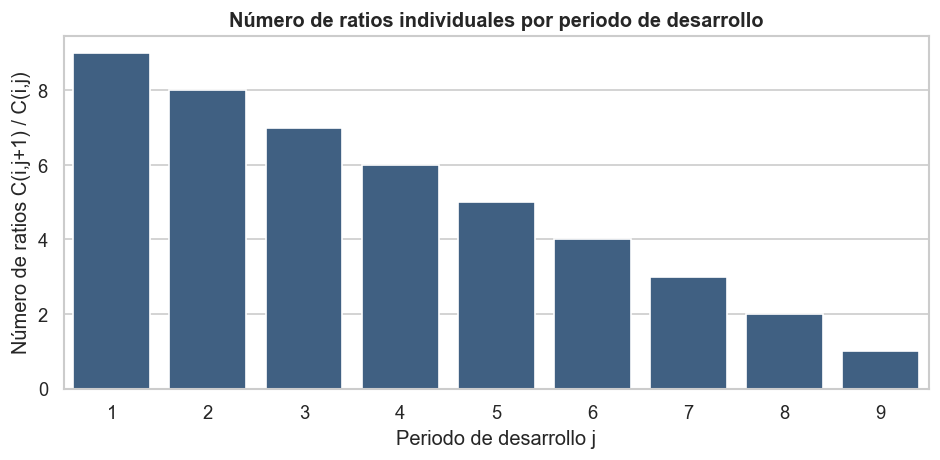

In [8]:
# Visualización del número de ratios usados para estimar factores de desarrollo
plt.figure(figsize=(8, 4))
sns.barplot(data=ratio_count_df, x="development_period", y="n_individual_ratios", color="#35608d")
plt.title("Número de ratios individuales por periodo de desarrollo")
plt.xlabel("Periodo de desarrollo j")
plt.ylabel("Número de ratios C(i,j+1) / C(i,j)")
plt.tight_layout()
plt.show()

## Métodos de estimación

Se comparan cuatro formas de estimar los factores de desarrollo y el IBNR:

- **Chain-Ladder clásico:** usa el promedio ponderado tradicional de los ratios de desarrollo.
- **Chain-Ladder con mediana:** reemplaza el promedio por la mediana de los ratios individuales para reducir el efecto de valores extremos.
- **Chain-Ladder con media truncada:** elimina una proporción de ratios en los extremos antes de calcular el promedio.
- **Chain-Ladder ponderado robusto:** reduce el peso de ratios alejados del comportamiento central mediante una escala robusta.

Todos los métodos se aplican sobre los mismos triángulos observados en cada réplica. Por ello, las diferencias de desempeño se atribuyen al método de estimación y no a cambios en los datos de entrada.

En términos operativos, el procedimiento de estimación sigue tres pasos:

1. Calcular ratios individuales de desarrollo a partir del triángulo acumulado observado.
2. Estimar factores agregados de desarrollo con cada método.
3. Proyectar la parte futura del triángulo y calcular el IBNR estimado.

La siguiente celda muestra una verificación mínima de salida para una réplica ilustrativa. La revisión completa del simulador está en el notebook de validación.

In [9]:
# Verificación mínima de los métodos sobre una réplica ilustrativa
rng_preview = np.random.default_rng(SEED)
preview_example = simulate_single_triangle(config, scenarios[4], rng_preview)
estimate_preview = estimate_ibnr_all_methods(preview_example.observed_cumulative, config)
estimate_preview

{'classical': MethodEstimate(method='classical', factors=array([1.59784887, 1.07892917, 1.09615327, 1.01433315, 1.00594955,
        1.00796461, 1.00713466, 1.00088535, 1.00045456]), projected_cumulative=array([[3542.79969301, 4104.37379154, 4218.44381106, 4309.50709336,
         4352.8489284 , 4372.66048698, 4380.43362593, 4397.69879095,
         4401.41062251, 4403.41133727],
        [ 448.08233996,  609.28458789,  718.3910132 ,  756.58381442,
          763.19419787,  777.67254085,  789.61652584,  811.42183741,
          812.32191839,  812.6911692 ],
        [1534.15113591, 1790.90415253, 2005.51655898, 2207.92642434,
         2221.37780587, 2238.44734256, 2270.92144033, 2284.93974999,
         2286.96272912, 2288.00229585],
        [ 144.85942632,  289.23649384,  370.43311391,  911.74232373,
          963.11958724,  972.38088662,  986.78305071,  993.82341013,
          994.70329504,  995.15544953],
        [ 484.3842496 , 3408.5664608 , 3594.21186769, 3650.78196154,
         3688.487

## Diseño Monte Carlo y estructura pareada

El experimento principal usa `1000` réplicas para cada escenario bajo distribución Gamma. En cada réplica, los cuatro métodos se aplican sobre el mismo triángulo observado. Esta estructura genera comparaciones pareadas: cada diferencia entre métodos se calcula con la misma información simulada, lo que reduce el ruido de comparación y permite evaluar directamente el efecto del método de estimación.

In [10]:
# Ejecución del experimento Monte Carlo principal
N_REPLICAS = 1000
results_df = run_experiment(config, scenarios, n_replicas=N_REPLICAS)
results_df["error"] = results_df["estimated_ibnr"] - results_df["true_ibnr"]
results_df["absolute_error"] = np.abs(results_df["error"])
results_df["percentage_error"] = results_df["error"] / results_df["true_ibnr"]
results_df["absolute_percentage_error"] = np.abs(results_df["percentage_error"])

scenario_meta = (
    results_df.groupby("scenario", as_index=False)
    .agg(
        contamination_proportion=("contamination_proportion", "first"),
        contamination_magnitude=("contamination_magnitude", "first"),
        contamination_location=("contamination_location", "first"),
    )
    .sort_values("scenario")
    .reset_index(drop=True)
)

results_df.head()

,scenario,replica,method,true_ibnr,estimated_ibnr,contamination_proportion,contamination_magnitude,contamination_location,error,absolute_error,percentage_error,absolute_percentage_error
0,base_sin_contaminacion,1,classical,"1,664.7808","1,326.4531",0.0000,1.0000,none,-338.3277,338.3277,-0.2032,0.2032
1,base_sin_contaminacion,1,median,"1,664.7808","1,198.5978",0.0000,1.0000,none,-466.1830,466.1830,-0.2800,0.2800
2,base_sin_contaminacion,1,trimmed,"1,664.7808","1,382.4168",0.0000,1.0000,none,-282.3640,282.3640,-0.1696,0.1696
3,base_sin_contaminacion,1,weighted,"1,664.7808","1,292.3040",0.0000,1.0000,none,-372.4768,372.4768,-0.2237,0.2237
4,base_sin_contaminacion,2,classical,"1,397.0800","1,846.8200",0.0000,1.0000,none,449.7400,449.7400,0.3219,0.3219


## Métricas principales

El desempeño se resume mediante sesgo, MSE, RMSE, MAE, MAPE, error porcentual medio y desviación estándar de las estimaciones. Para las métricas basadas en promedios también se reporta una aproximación al error estándar Monte Carlo y un intervalo de confianza normal aproximado. El RMSE permanece como métrica principal de comparación, por su lectura directa en la escala del IBNR.

Las métricas principales se interpretan del siguiente modo:

$$
\begin{aligned}
\mathrm{Bias} &= \frac{1}{N}\sum_{s=1}^{N}(\widehat{IBNR}_s - IBNR_s), \\
\mathrm{RMSE} &= \sqrt{\frac{1}{N}\sum_{s=1}^{N}(\widehat{IBNR}_s - IBNR_s)^2}.
\end{aligned}
$$

$$
\begin{aligned}
\mathrm{MAPE} &= \frac{1}{N}\sum_{s=1}^{N}\left|\frac{\widehat{IBNR}_s - IBNR_s}{IBNR_s}\right|, \\
\operatorname{SD}(\widehat{IBNR}) &= \sqrt{\frac{1}{N-1}\sum_{s=1}^{N}(\widehat{IBNR}_s - \overline{\widehat{IBNR}})^2}.
\end{aligned}
$$

- Un **RMSE** menor indica mejor precisión global.
- Un **MAPE** menor indica menor error relativo medio.
- Un **sesgo** cercano a cero indica ausencia de sobreestimación o subestimación sistemática.
- Una **desviación estándar** menor indica mayor estabilidad entre réplicas.

Por ello, un método favorable no es necesariamente el que minimiza una sola métrica, sino el que presenta un compromiso razonable entre precisión, estabilidad y comportamiento sistemático.

In [11]:
# Cálculo de métricas de desempeño por método y escenario
metrics_df = compute_method_metrics(results_df).merge(scenario_meta, on="scenario", how="left")
metrics_df.head(12)

,scenario,method,n_replicas,bias,mse,rmse,mae,mape,mean_percentage_error,sd_estimates,overestimation_rate,underestimation_rate,median_absolute_error,mcse_bias,mcse_mape,mcse_mae,bias_ci_lower,bias_ci_upper,mape_ci_lower,mape_ci_upper,mae_ci_lower,mae_ci_upper,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,classical,"1,000.0000",59.2324,"364,847.1156",604.0258,461.2835,0.2857,0.0609,552.0171,0.4880,0.5120,379.5974,19.0184,0.0082,12.3376,21.9563,96.5085,0.2697,0.3018,437.1017,485.4652,0.0000,1.0000,none
1,base_sin_contaminacion,median,"1,000.0000",26.8078,"392,604.7807",626.5818,470.5115,0.2898,0.0401,581.5762,0.4630,0.5370,383.8660,19.8060,0.0086,13.0918,-12.0120,65.6276,0.2730,0.3065,444.8516,496.1715,0.0000,1.0000,none
2,base_sin_contaminacion,trimmed,"1,000.0000",429.7695,"801,499.5097",895.2650,639.5323,0.4066,0.2905,751.0393,0.6790,0.3210,454.1450,24.8478,0.0133,19.8215,381.0677,478.4712,0.3805,0.4326,600.6822,678.3824,0.0000,1.0000,none
3,base_sin_contaminacion,weighted,"1,000.0000",153.1254,"465,998.0309",682.6405,503.1575,0.3141,0.1187,623.7715,0.5420,0.4580,387.3081,21.0474,0.0097,14.5960,111.8725,194.3783,0.2951,0.3332,474.5493,531.7657,0.0000,1.0000,none
4,p10_m10_early,classical,"1,000.0000","1,020.3689","13,627,808.2543","3,691.5861","1,599.1127",0.9770,0.6480,"3,542.2803",0.5270,0.4730,698.5532,112.2464,0.0645,105.2698,800.3659,"1,240.3718",0.8506,1.1034,"1,392.7839","1,805.4414",0.1000,10.0000,early
5,p10_m10_early,median,"1,000.0000","1,027.1492","10,771,796.7882","3,282.0416","1,455.7309",0.8918,0.6543,"3,108.2774",0.5450,0.4550,536.9277,98.6230,0.0584,93.0661,833.8482,"1,220.4502",0.7773,1.0063,"1,273.3213","1,638.1405",0.1000,10.0000,early
6,p10_m10_early,trimmed,"1,000.0000","2,756.7299","47,302,421.7347","6,877.6756","2,872.4667",1.7719,1.7095,"6,300.7148",0.8470,0.1530,"1,071.4714",199.3555,0.1195,197.7130,"2,365.9932","3,147.4666",1.5377,2.0060,"2,484.9492","3,259.9843",0.1000,10.0000,early
7,p10_m10_early,weighted,"1,000.0000","1,302.4348","13,253,566.0152","3,640.5447","1,626.9002",1.0007,0.8236,"3,391.1865",0.6270,0.3730,580.1616,107.5583,0.0647,103.0407,"1,091.6204","1,513.2491",0.8739,1.1276,"1,424.9405","1,828.8599",0.1000,10.0000,early
8,p10_m10_late,classical,"1,000.0000","1,615.7664","10,454,902.7793","3,233.4042","1,687.7264",1.0574,1.0197,"2,782.9213",0.8600,0.1400,856.8758,88.6118,0.0550,87.2588,"1,442.0872","1,789.4455",0.9495,1.1653,"1,516.6992","1,858.7537",0.1000,10.0000,late
9,p10_m10_late,median,"1,000.0000",969.0871,"7,989,137.1760","2,826.5062","1,235.0187",0.7693,0.6243,"2,635.1597",0.6520,0.3480,512.2392,84.0063,0.0503,80.4384,804.4347,"1,133.7395",0.6707,0.8678,"1,077.3594","1,392.6779",0.1000,10.0000,late


In [12]:
# Ranking de métodos según RMSE y resumen global de desempeño
ranking_df = rank_methods_within_scenario(metrics_df, metric="rmse")
dominance_df = summarize_method_dominance(ranking_df)
global_summary = build_global_summary(metrics_df)

print("Método ganador por número de escenarios:")
display(dominance_df)
print("Resumen global por método:")
display(global_summary)

Método ganador por número de escenarios:


,method,n_scenarios_won
0,median,18
1,classical,10


Resumen global por método:


,method,mean_rmse,mean_mape,mean_abs_bias,mean_sd
0,median,"1,834.4606",0.6239,659.4319,"1,665.1370"
1,weighted,"2,134.8781",0.7330,924.2811,"1,883.7907"
2,classical,"2,236.1561",0.7809,950.9761,"1,966.6577"
3,trimmed,"3,841.8638",1.3825,"2,112.2293","3,168.2748"


Las dos tablas anteriores cumplen funciones distintas. La primera cuenta cuántos escenarios gana cada método cuando el criterio de comparación es el RMSE. La segunda resume su comportamiento promedio en el conjunto total del experimento. La combinación de ambas tablas permite separar dos preguntas distintas: qué método domina globalmente y qué método conserva ventajas en escenarios específicos.

In [13]:
# Resumen comparativo entre escenario limpio y escenarios contaminados
environment_summary = (
    metrics_df.assign(
        entorno=lambda df: np.where(df["scenario"].eq("base_sin_contaminacion"), "Sin contaminación", "Escenarios contaminados")
    )
    .groupby(["entorno", "method"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mape=("mape", "mean"),
        mean_sd=("sd_estimates", "mean"),
    )
)

best_by_scenario = (
    ranking_df.loc[ranking_df["rank"] == 1, ["scenario", "method", "rmse", "mape", "bias",
                                             "contamination_proportion", "contamination_magnitude",
                                             "contamination_location"]]
    .sort_values(["contamination_proportion", "contamination_magnitude", "contamination_location"])
    .reset_index(drop=True)
)

print("Resumen por entorno:")
display(environment_summary)
print("Método ganador por escenario:")
display(best_by_scenario.head(15))

Resumen por entorno:


,entorno,method,mean_rmse,mean_mape,mean_sd
0,Escenarios contaminados,classical,"2,296.6054",0.7992,"2,019.0518"
1,Escenarios contaminados,median,"1,879.1969",0.6362,"1,705.2689"
2,Escenarios contaminados,trimmed,"3,950.9970",1.4187,"3,257.8020"
3,Escenarios contaminados,weighted,"2,188.6647",0.7485,"1,930.4580"
4,Sin contaminación,classical,604.0258,0.2857,552.0171
5,Sin contaminación,median,626.5818,0.2898,581.5762
6,Sin contaminación,trimmed,895.2650,0.4066,751.0393
7,Sin contaminación,weighted,682.6405,0.3141,623.7715


Método ganador por escenario:


,scenario,method,rmse,mape,bias,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,classical,604.0258,0.2857,59.2324,0.0000,1.0000,none
1,p5_m2_early,classical,673.7219,0.3077,75.1421,0.0500,2.0000,early
2,p5_m2_late,classical,690.8426,0.3047,140.4212,0.0500,2.0000,late
3,p5_m2_random,classical,729.6043,0.3301,151.9826,0.0500,2.0000,random
4,p5_m5_early,classical,"1,060.5838",0.4020,182.9171,0.0500,5.0000,early
5,p5_m5_late,median,"1,171.0081",0.3967,259.5242,0.0500,5.0000,late
6,p5_m5_random,median,"1,094.0529",0.4061,292.0869,0.0500,5.0000,random
7,p5_m10_early,classical,"2,220.8161",0.6450,549.5004,0.0500,10.0000,early
8,p5_m10_late,median,"2,102.0680",0.5434,530.8517,0.0500,10.0000,late
9,p5_m10_random,median,"2,726.6338",0.7424,904.3546,0.0500,10.0000,random


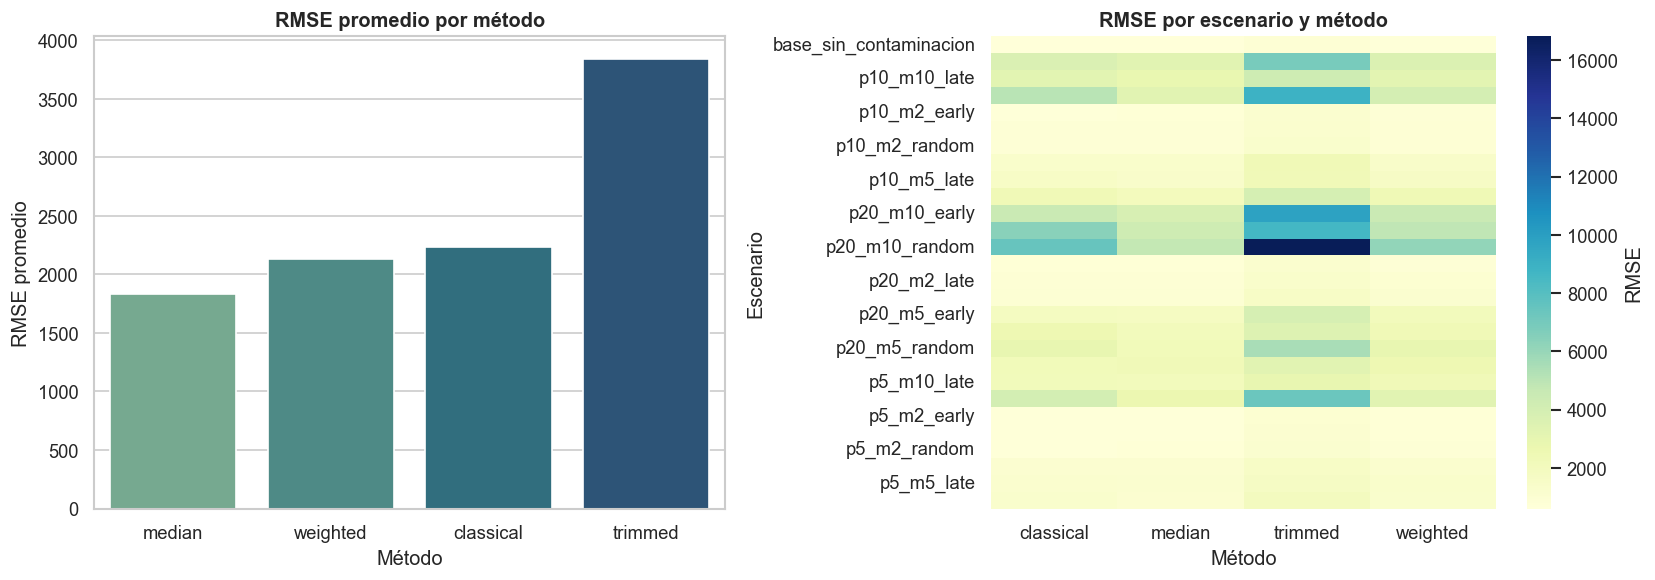

In [14]:
# Visualización general del RMSE por método y por escenario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=global_summary, x="method", y="mean_rmse", hue="method", palette="crest", legend=False, ax=axes[0])
axes[0].set_title("RMSE promedio por método")
axes[0].set_xlabel("Método")
axes[0].set_ylabel("RMSE promedio")

heatmap_data = (
    metrics_df.pivot_table(index="scenario", columns="method", values="rmse")
    .reindex(sorted(metrics_df["scenario"].unique()))
)
sns.heatmap(heatmap_data, cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "RMSE"})
axes[1].set_title("RMSE por escenario y método")
axes[1].set_xlabel("Método")
axes[1].set_ylabel("Escenario")

plt.tight_layout()
plt.show()

La lectura conjunta del gráfico de barras y del mapa de calor permite identificar dos hechos centrales. En primer lugar, el método con mejor desempeño global no siempre coincide con el más eficiente en el escenario base. En segundo lugar, la intensidad de color del mapa de calor permite detectar si el deterioro del método clásico ocurre de forma aislada o si se concentra sistemáticamente en combinaciones de alta proporción y alta magnitud de contaminación.

## Comparaciones pareadas frente al método clásico

La evaluación anterior resume el desempeño medio por escenario. Sin embargo, dado que los métodos se aplican sobre las mismas réplicas, es posible comparar sus errores en forma pareada. Una diferencia negativa en `delta_mse_mean` indica que el método robusto presenta menor error cuadrático medio que el método clásico en el mismo conjunto de réplicas.

In [15]:
# Comparación pareada de cada método robusto contra Chain-Ladder clásico
comparisons_df = compare_methods_to_baseline(results_df, baseline="classical")
comparisons_df = comparisons_df.merge(scenario_meta, on="scenario", how="left")
comparisons_df.head(12)

,scenario,method,baseline,n_replicas,delta_mse_mean,delta_mse_se,delta_mse_ci_lower,delta_mse_ci_upper,delta_mse_improves,delta_mse_worsens,delta_mae_mean,delta_mae_se,delta_mae_ci_lower,delta_mae_ci_upper,delta_mae_improves,delta_mae_worsens,delta_mape_mean,delta_mape_se,delta_mape_ci_lower,delta_mape_ci_upper,delta_mape_improves,delta_mape_worsens,contamination_proportion,contamination_magnitude,contamination_location
0,base_sin_contaminacion,median,classical,1000,"27,757.6651","11,259.0924","5,689.8439","49,825.4862",False,True,9.2281,5.5913,-1.7308,20.1870,False,False,0.0040,0.0035,-0.0029,0.0110,False,False,0.0000,1.0000,none
1,base_sin_contaminacion,trimmed,classical,1000,"436,652.3941","38,038.8168","362,096.3132","511,208.4750",False,True,178.2489,12.8951,152.9745,203.5233,False,True,0.1208,0.0080,0.1051,0.1366,False,True,0.0000,1.0000,none
2,base_sin_contaminacion,weighted,classical,1000,"101,150.9153","15,352.7035","71,059.6164","131,242.2142",False,True,41.8741,5.6406,30.8185,52.9296,False,True,0.0284,0.0035,0.0215,0.0353,False,True,0.0000,1.0000,none
3,p10_m10_early,median,classical,1000,"-2,856,011.4660","1,841,434.4423","-6,465,222.9729","753,200.0409",False,False,-143.3817,47.9620,-237.3872,-49.3763,True,False,-0.0852,0.0297,-0.1435,-0.0269,True,False,0.1000,10.0000,early
4,p10_m10_early,trimmed,classical,1000,"33,674,613.4804","12,837,247.7307","8,513,607.9282","58,835,619.0327",False,True,"1,273.3541",106.5956,"1,064.4267","1,482.2814",False,True,0.7949,0.0638,0.6698,0.9200,False,True,0.1000,10.0000,early
5,p10_m10_early,weighted,classical,1000,"-374,242.2391","1,875,763.5675","-4,050,738.8313","3,302,254.3532",False,False,27.7876,48.2538,-66.7899,122.3650,False,False,0.0238,0.0295,-0.0341,0.0817,False,False,0.1000,10.0000,early
6,p10_m10_late,median,classical,1000,"-2,465,765.6032","716,803.6986","-3,870,700.8524","-1,060,830.3541",True,False,-452.7078,28.1735,-507.9279,-397.4876,True,False,-0.2881,0.0172,-0.3217,-0.2545,True,False,0.1000,10.0000,late
7,p10_m10_late,trimmed,classical,1000,"8,377,200.8091","1,236,397.5927","5,953,861.5274","10,800,540.0908",False,True,664.9827,35.5413,595.3217,734.6437,False,True,0.4100,0.0220,0.3668,0.4531,False,True,0.1000,10.0000,late
8,p10_m10_late,weighted,classical,1000,"-532,809.0970","580,221.0137","-1,670,042.2839","604,424.0899",False,False,-285.5208,23.2372,-331.0658,-239.9759,True,False,-0.1814,0.0139,-0.2087,-0.1540,True,False,0.1000,10.0000,late
9,p10_m10_random,median,classical,1000,"-14,542,702.2392","2,460,951.5952","-19,366,167.3658","-9,719,237.1126",True,False,-974.1412,72.5202,"-1,116.2808",-832.0016,True,False,-0.6108,0.0459,-0.7008,-0.5207,True,False,0.1000,10.0000,random


In [16]:
# Resumen de escenarios donde cada método robusto mejora o empeora frente al clásico
comparison_summary = (
    comparisons_df.groupby("method", as_index=False)
    .agg(
        escenarios_con_mejora_mse=("delta_mse_improves", "sum"),
        escenarios_con_deterioro_mse=("delta_mse_worsens", "sum"),
        escenarios_con_mejora_mape=("delta_mape_improves", "sum"),
        delta_mse_promedio=("delta_mse_mean", "mean"),
        delta_mape_promedio=("delta_mape_mean", "mean"),
    )
    .sort_values("escenarios_con_mejora_mse", ascending=False)
)
comparison_summary

,method,escenarios_con_mejora_mse,escenarios_con_deterioro_mse,escenarios_con_mejora_mape,delta_mse_promedio,delta_mape_promedio
0,median,11,3,16,"-3,527,984.2102",-0.1570
2,weighted,5,15,8,"-1,649,839.5349",-0.0479
1,trimmed,0,28,0,"19,619,971.2522",0.6016


En esta tabla, una mejora significa que el método robusto reduce el error respecto del método clásico sobre las mismas réplicas. Por ejemplo, si `escenarios_con_mejora_mse` es alto para la mediana, ello indica que la ventaja observada no se debe solo a uno o dos escenarios extremos, sino a un patrón repetido en distintos contextos de contaminación.

## Sensibilidad por escenario representativo

La combinación de gráficos de distribución y tablas de ranking permite identificar de forma concreta dónde se produce el deterioro del método clásico y bajo qué tipos de contaminación aparecen ventajas robustas.

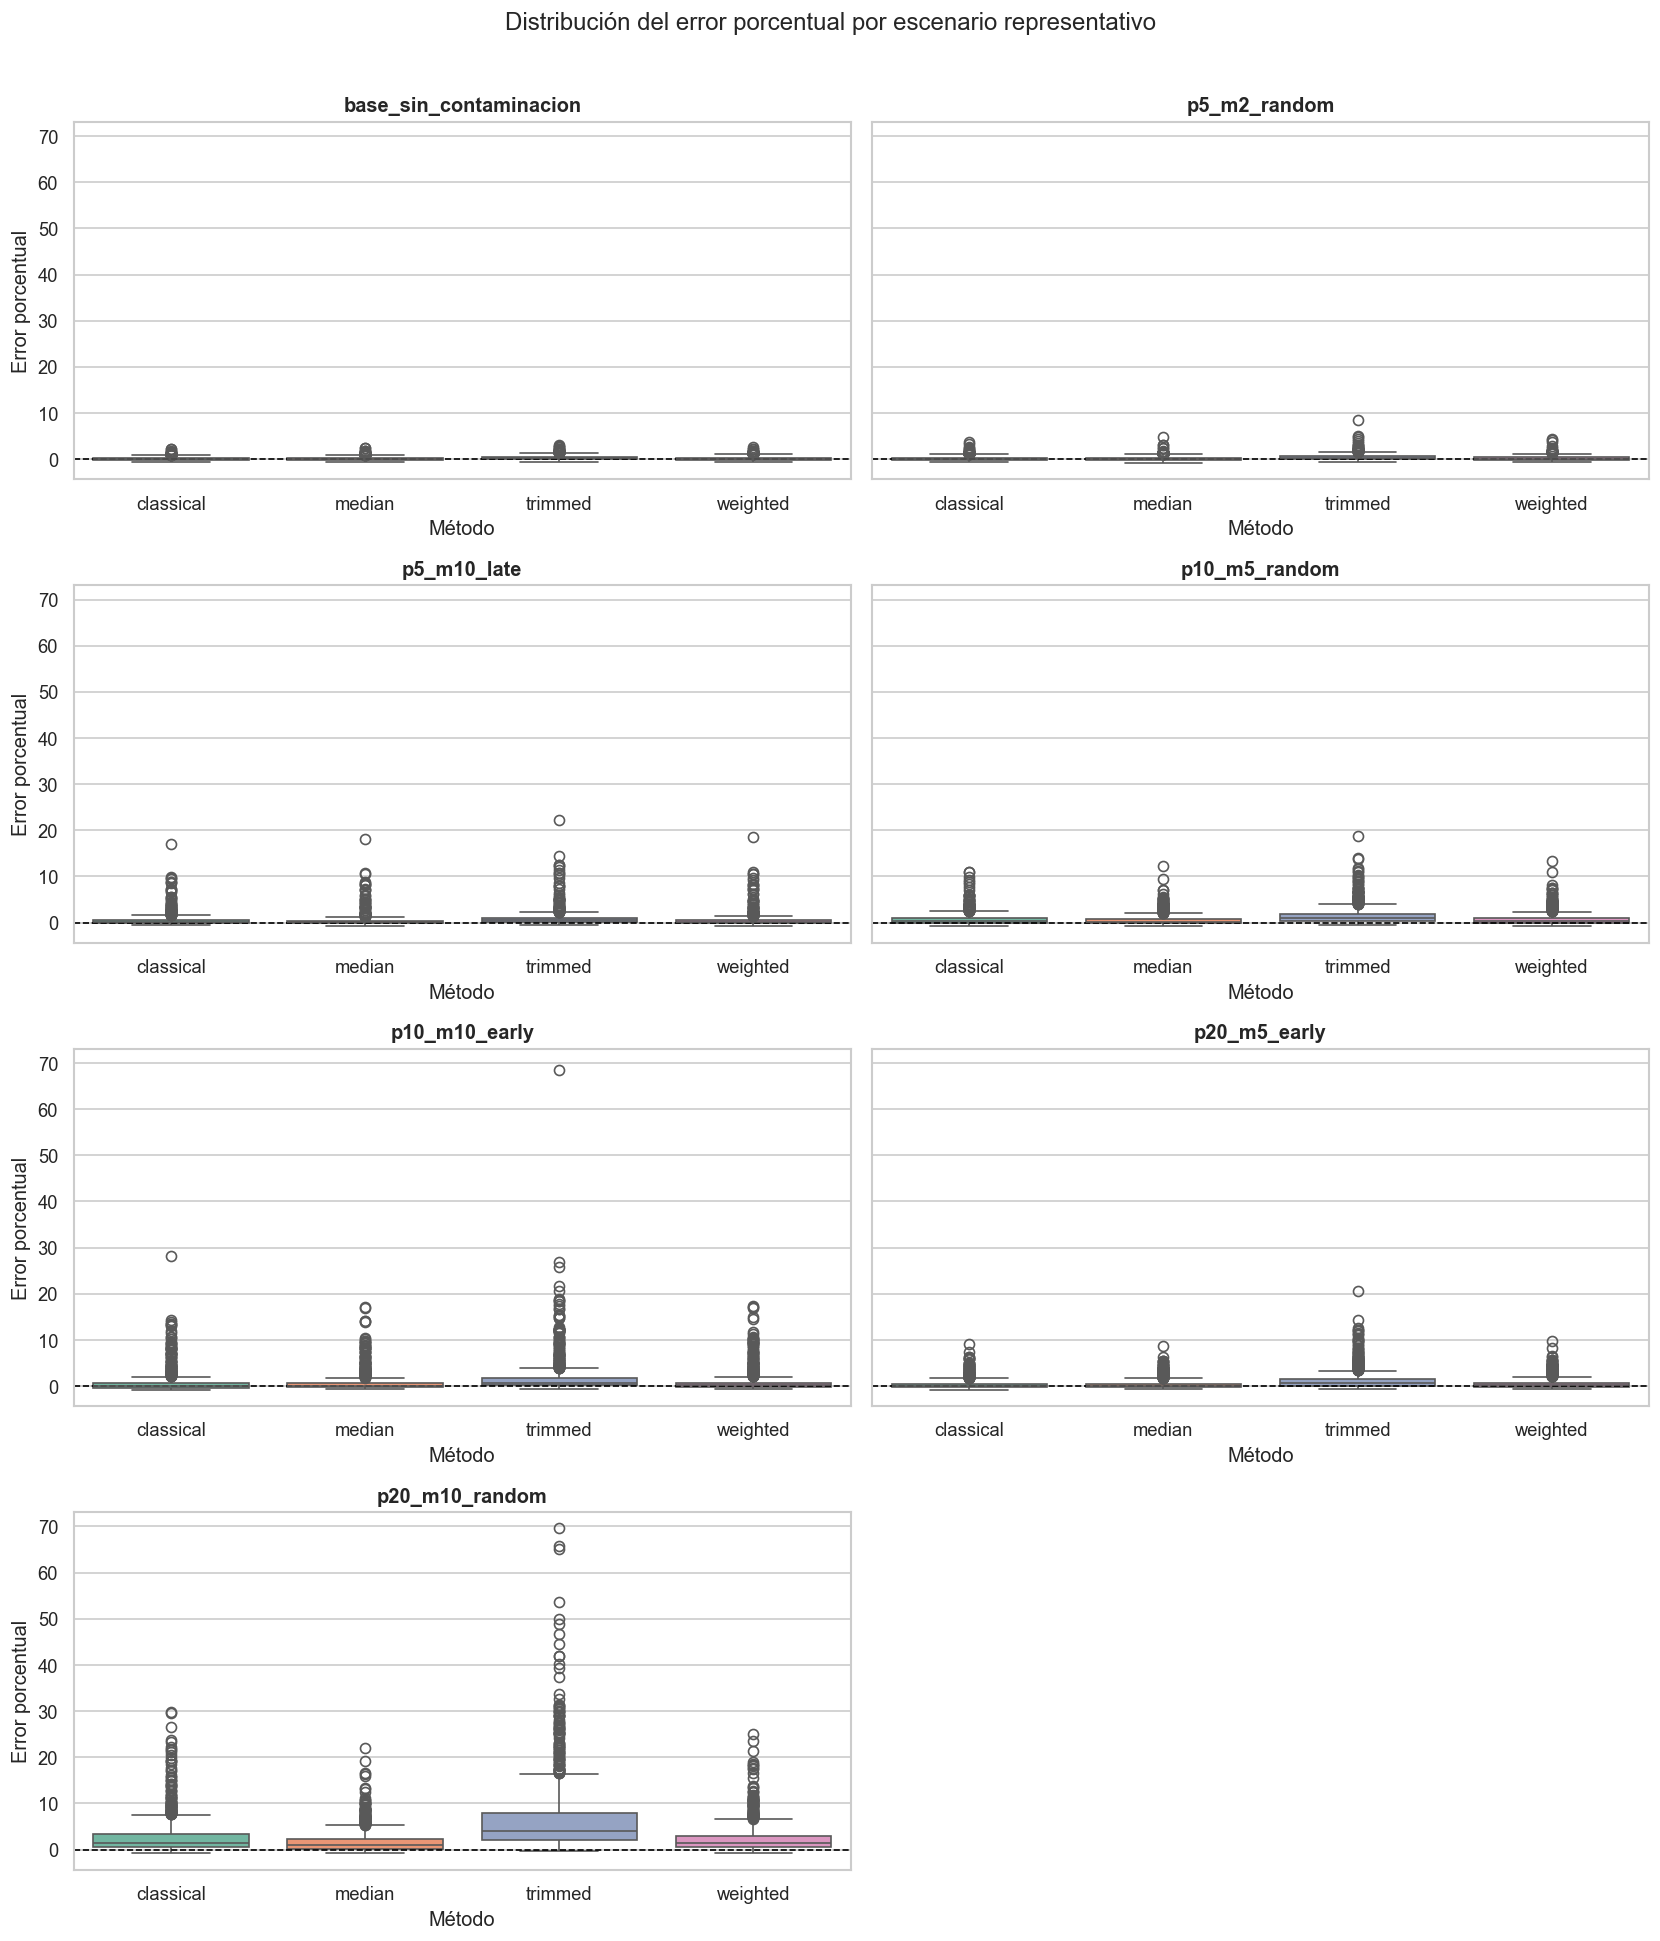

In [17]:
# Boxplots separados para evitar saturación visual en los escenarios representativos
selected_scenarios = [
    "base_sin_contaminacion",
    "p5_m2_random",
    "p5_m10_late",
    "p10_m5_random",
    "p10_m10_early",
    "p20_m5_early",
    "p20_m10_random",
]

n_cols = 2
n_rows = int(np.ceil(len(selected_scenarios) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, scenario in zip(axes, selected_scenarios):
    sns.boxplot(
        data=results_df.query("scenario == @scenario"),
        x="method",
        y="percentage_error",
        hue="method",
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(scenario)
    ax.set_xlabel("Método")
    ax.set_ylabel("Error porcentual")

for ax in axes[len(selected_scenarios):]:
    ax.axis("off")

plt.suptitle("Distribución del error porcentual por escenario representativo", y=1.01)
plt.tight_layout()
plt.show()

En este gráfico, la línea horizontal en cero representa estimación sin error. Valores por encima de cero indican sobreestimación y valores por debajo de cero indican subestimación. La dispersión vertical de cada caja refleja estabilidad: cajas más altas o colas más largas indican mayor variabilidad del método. Esta visualización resulta más informativa que comparar niveles absolutos del IBNR, porque normaliza los errores respecto del tamaño real del IBNR en cada escenario.

## Justificación empírica del número de réplicas

El número de réplicas no se adopta únicamente por convención. La trayectoria acumulada del RMSE muestra si la estimación del desempeño se estabiliza conforme aumenta el tamaño de la simulación. La evidencia siguiente se presenta para dos situaciones contrastantes: el escenario base con el método clásico y un escenario severamente contaminado con la mediana.

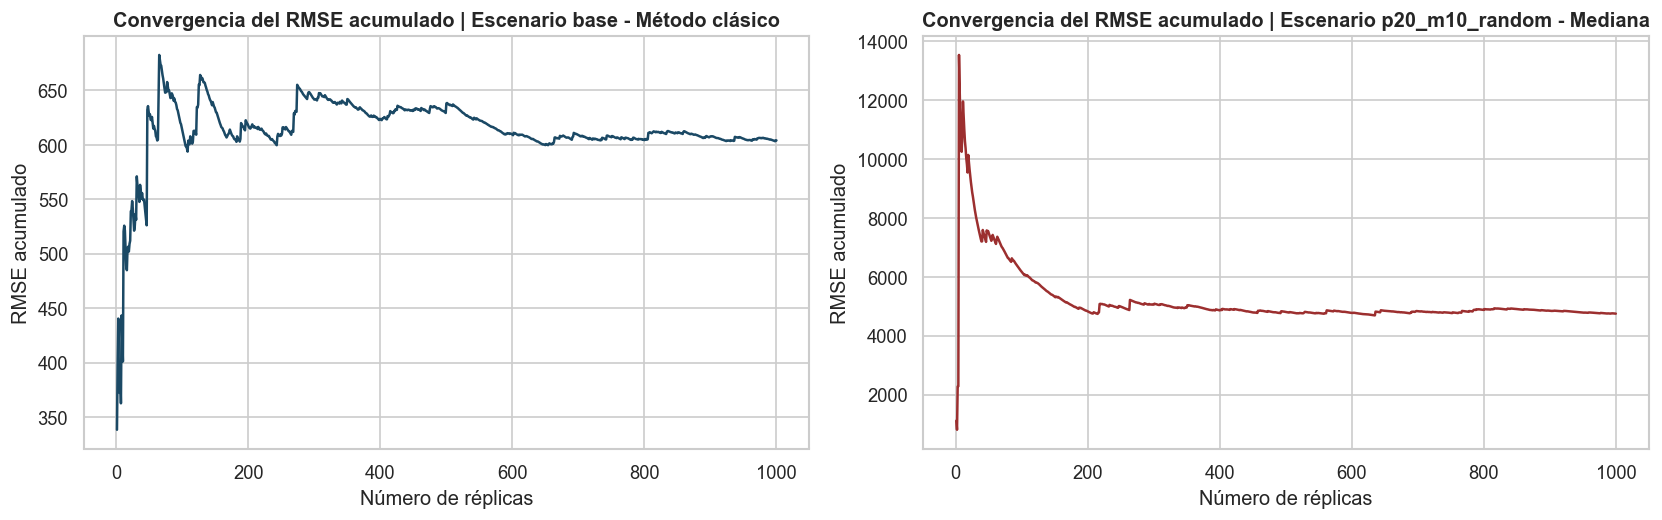

In [18]:
# Revisión de estabilidad empírica del número de réplicas usado
running_base = compute_running_statistics(results_df, "base_sin_contaminacion", "classical")
running_severe = compute_running_statistics(results_df, "p20_m10_random", "median")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(data=running_base, x="replica", y="running_rmse", color="#1b4965", ax=axes[0])
axes[0].set_title("Convergencia del RMSE acumulado | Escenario base - Método clásico")
axes[0].set_xlabel("Número de réplicas")
axes[0].set_ylabel("RMSE acumulado")

sns.lineplot(data=running_severe, x="replica", y="running_rmse", color="#9c2f2f", ax=axes[1])
axes[1].set_title("Convergencia del RMSE acumulado | Escenario p20_m10_random - Mediana")
axes[1].set_xlabel("Número de réplicas")
axes[1].set_ylabel("RMSE acumulado")

plt.tight_layout()
plt.show()

## Evaluación de hipótesis

La hipótesis del estudio se evalúa con tres fuentes de evidencia: el comportamiento del error del método clásico, la variabilidad relativa de las variantes robustas y la comparación por escenarios contaminados.

In [19]:
# Evaluación sintética de la hipótesis con base en métricas observadas
classical_metrics = metrics_df.query("scenario != 'base_sin_contaminacion' and method == 'classical'").copy()
classical_metrics["log_magnitude"] = np.log(classical_metrics["contamination_magnitude"])
correlation_table = classical_metrics[
    ["contamination_proportion", "contamination_magnitude", "log_magnitude", "rmse", "mape", "sd_estimates"]
].corr(method="spearman")

support_sd = (
    metrics_df.query("scenario != 'base_sin_contaminacion'")
    .pivot(index="scenario", columns="method", values="sd_estimates")
    .assign(
        median_less_than_classical=lambda df: df["median"] < df["classical"],
        trimmed_less_than_classical=lambda df: df["trimmed"] < df["classical"],
        weighted_less_than_classical=lambda df: df["weighted"] < df["classical"],
    )
)

robust_sd_summary = pd.DataFrame(
    {
        "metodo_robusto": ["median", "trimmed", "weighted"],
        "escenarios_con_menor_sd_que_clasico": [
            int(support_sd["median_less_than_classical"].sum()),
            int(support_sd["trimmed_less_than_classical"].sum()),
            int(support_sd["weighted_less_than_classical"].sum()),
        ],
    }
)
robust_sd_summary["total_escenarios_contaminados"] = len(support_sd)
robust_sd_summary["proporcion_favorable"] = (
    robust_sd_summary["escenarios_con_menor_sd_que_clasico"]
    / robust_sd_summary["total_escenarios_contaminados"]
)

best_stability_row = robust_sd_summary.sort_values("escenarios_con_menor_sd_que_clasico", ascending=False).iloc[0]
best_stability_method = best_stability_row["metodo_robusto"]
best_stability_count = int(best_stability_row["escenarios_con_menor_sd_que_clasico"])

hypothesis_table = pd.DataFrame(
    [
        {
            "hipotesis": "H1",
            "evidencia_principal": (
                f"Correlación de Spearman del RMSE clásico con proporción = "
                f"{correlation_table.loc['contamination_proportion', 'rmse']:.3f}, "
                f"con magnitud = {correlation_table.loc['contamination_magnitude', 'rmse']:.3f}. "
                f"En variabilidad, el método robusto con mejor resultado es {best_stability_method}, "
                f"que mejora al clásico en {best_stability_count} de {len(support_sd)} escenarios contaminados."
            ),
            "dictamen": "Apoyada" if (
                correlation_table.loc["contamination_proportion", "rmse"] > 0
                and correlation_table.loc["contamination_magnitude", "rmse"] > 0
                and best_stability_count >= len(support_sd) / 2
            ) else "Parcialmente apoyada",
        },
    ]
)

print("Correlaciones de Spearman para el método clásico en escenarios contaminados:")
display(correlation_table)
print("Resumen de estabilidad relativa de los métodos robustos:")
display(robust_sd_summary)
print("Evaluación sintética de la hipótesis:")
display(hypothesis_table)

Correlaciones de Spearman para el método clásico en escenarios contaminados:


,contamination_proportion,contamination_magnitude,log_magnitude,rmse,mape,sd_estimates
contamination_proportion,1.0000,0.0000,0.0000,0.3320,0.3902,0.3028
contamination_magnitude,0.0000,1.0000,1.0000,0.9085,0.8677,0.9260
log_magnitude,0.0000,1.0000,1.0000,0.9085,0.8677,0.9260
rmse,0.3320,0.9085,0.9085,1.0000,0.9902,0.9951
mape,0.3902,0.8677,0.8677,0.9902,1.0000,0.9829
sd_estimates,0.3028,0.9260,0.9260,0.9951,0.9829,1.0000


Resumen de estabilidad relativa de los métodos robustos:


,metodo_robusto,escenarios_con_menor_sd_que_clasico,total_escenarios_contaminados,proporcion_favorable
0,median,16,27,0.5926
1,trimmed,0,27,0.0000
2,weighted,9,27,0.3333


Evaluación sintética de la hipótesis:


,hipotesis,evidencia_principal,dictamen
0,H1,Correlación de Spearman del RMSE clásico con p...,Apoyada


In [20]:
# Síntesis de hallazgos principales del experimento Gamma
clean_winner = best_by_scenario.loc[best_by_scenario["scenario"] == "base_sin_contaminacion", "method"].iloc[0]
contaminated_wins = (
    best_by_scenario.query("scenario != 'base_sin_contaminacion'")
    .groupby("method")
    .size()
    .to_dict()
)
top_median_advantages = (
    comparisons_df.query("method == 'median'")
    .sort_values("delta_mse_mean")
    .loc[:, ["scenario", "delta_mse_mean", "delta_mape_mean",
             "contamination_proportion", "contamination_magnitude", "contamination_location"]]
    .head(5)
)

key_results_df = pd.DataFrame(
    [
        {"hallazgo": "Método ganador en el escenario base", "resultado": clean_winner},
        {
            "hallazgo": "Escenarios contaminados ganados por la mediana",
            "resultado": contaminated_wins.get("median", 0),
        },
        {
            "hallazgo": "Escenarios contaminados ganados por el método clásico",
            "resultado": contaminated_wins.get("classical", 0),
        },
        {
            "hallazgo": "Método con menor RMSE promedio global",
            "resultado": global_summary.iloc[0]["method"],
        },
    ]
)

print("Hallazgos principales del experimento Gamma:")
display(key_results_df)
print("Escenarios con mayor ventaja de la mediana frente al método clásico:")
display(top_median_advantages)

Hallazgos principales del experimento Gamma:


,hallazgo,resultado
0,Método ganador en el escenario base,classical
1,Escenarios contaminados ganados por la mediana,18
2,Escenarios contaminados ganados por el método ...,9
3,Método con menor RMSE promedio global,median


Escenarios con mayor ventaja de la mediana frente al método clásico:


,scenario,delta_mse_mean,delta_mape_mean,contamination_proportion,contamination_magnitude,contamination_location
36,p20_m10_random,"-33,639,670.3376",-0.9750,0.2000,10.0000,random
33,p20_m10_late,"-22,366,541.0671",-0.9645,0.2000,10.0000,late
9,p10_m10_random,"-14,542,702.2392",-0.6108,0.1000,10.0000,random
63,p5_m10_random,"-9,254,034.0677",-0.4047,0.0500,10.0000,random
30,p20_m10_early,"-5,373,558.6513",-0.0662,0.2000,10.0000,early


La evidencia obtenida muestra un patrón robusto. En datos limpios o con contaminación leve, el método clásico conserva ventajas de eficiencia. Sin embargo, conforme aumentan la magnitud y la frecuencia de la contaminación, la mediana se convierte en la opción más estable y precisa. En esta implementación, la media truncada no confirma la hipótesis de equilibrio robustez-eficiencia y la versión ponderada no domina de forma sistemática. Ese resultado no invalida el diseño; por el contrario, aporta una conclusión empírica relevante: no toda robustificación heurística resulta efectiva en triángulos con tamaños muestrales decrecientes por periodo de desarrollo.

## Sensibilidad a colas más pesadas

Como extensión prevista en la metodología, se repite el experimento bajo una distribución Lognormal. Con el fin de mantener un tiempo de ejecución razonable dentro del cuaderno, esta sensibilidad se evalúa con 400 réplicas por escenario. Su propósito es verificar si el orden relativo entre métodos cambia cuando la generación de incrementales presenta colas más pesadas.

In [21]:
# Experimento complementario con distribución Lognormal
N_REPLICAS_LOGNORMAL = 400
config_lognormal = clone_config(config, distribution="lognormal", random_seed=SEED + 1)
results_lognormal = run_experiment(config_lognormal, scenarios, n_replicas=N_REPLICAS_LOGNORMAL)
metrics_lognormal = compute_method_metrics(results_lognormal)
ranking_lognormal = rank_methods_within_scenario(metrics_lognormal, metric="rmse")
global_summary_lognormal = build_global_summary(metrics_lognormal)
dominance_lognormal = summarize_method_dominance(ranking_lognormal)

print("Resumen global bajo Lognormal:")
display(global_summary_lognormal)
print("Dominancia por escenarios bajo Lognormal:")
display(dominance_lognormal)

Resumen global bajo Lognormal:


,method,mean_rmse,mean_mape,mean_abs_bias,mean_sd
0,median,"1,721.8761",0.5903,613.8463,"1,558.4188"
1,weighted,"1,955.1885",0.6812,841.8089,"1,718.8927"
2,classical,"2,149.8931",0.7589,924.7558,"1,875.3730"
3,trimmed,"3,427.2697",1.2510,"1,893.1137","2,813.1149"


Dominancia por escenarios bajo Lognormal:


,method,n_scenarios_won
0,median,22
1,classical,6


In [22]:
# Comparación resumida entre resultados Gamma y Lognormal
gamma_vs_lognormal = (
    global_summary.loc[:, ["method", "mean_rmse", "mean_mape"]]
    .rename(columns={"mean_rmse": "gamma_mean_rmse", "mean_mape": "gamma_mean_mape"})
    .merge(
        global_summary_lognormal.loc[:, ["method", "mean_rmse", "mean_mape"]]
        .rename(columns={"mean_rmse": "lognormal_mean_rmse", "mean_mape": "lognormal_mean_mape"}),
        on="method",
        how="inner",
    )
    .sort_values("gamma_mean_rmse")
    .reset_index(drop=True)
)
gamma_vs_lognormal

,method,gamma_mean_rmse,gamma_mean_mape,lognormal_mean_rmse,lognormal_mean_mape
0,median,"1,834.4606",0.6239,"1,721.8761",0.5903
1,weighted,"2,134.8781",0.7330,"1,955.1885",0.6812
2,classical,"2,236.1561",0.7809,"2,149.8931",0.7589
3,trimmed,"3,841.8638",1.3825,"3,427.2697",1.2510


La comparación anterior permite verificar si el orden relativo entre métodos cambia cuando la distribución subyacente presenta colas más pesadas. Si el método ganador se mantiene, la conclusión principal del estudio resulta más robusta; si cambia, ello indicaría que parte del hallazgo depende de la forma específica del proceso generador de datos.

## Conclusiones del experimento

El conjunto de resultados permite extraer cuatro conclusiones principales:

1. **El método clásico conserva eficiencia en datos limpios o débilmente contaminados.** Esto es consistente con la idea de que la robustificación puede implicar un costo cuando no hay observaciones extremas influyentes.
2. **La mediana ofrece la respuesta más consistente cuando la contaminación aumenta en magnitud o frecuencia.** En el diseño implementado, este método concentra la mayor cantidad de victorias por escenario y exhibe el mejor desempeño global en los escenarios contaminados.
3. **La media truncada y el método ponderado no dominan de forma general.** En particular, la media truncada no confirma la hipótesis de equilibrio robustez-eficiencia bajo la parametrización considerada, mientras que el método ponderado mejora en algunos contextos, pero no alcanza una ventaja sistemática.
4. **La conclusión principal es estable bajo la sensibilidad Lognormal.** El patrón general observado con Gamma no desaparece al introducir colas más pesadas, lo que fortalece la interpretación sustantiva del experimento.

En términos de la pregunta de investigación, la evidencia sugiere que los métodos robustos sí ofrecen mejoras frente al Chain-Ladder clásico, pero no de manera uniforme: la ventaja aparece principalmente cuando los outliers son lo suficientemente severos o frecuentes como para distorsionar los factores de desarrollo clásicos.

## Exportación de resultados

Con fines de trazabilidad y documentación del repositorio, los principales resultados se exportan a la carpeta `results`. Esto permite desacoplar la ejecución del cuaderno del uso posterior de tablas y figuras en el documento escrito.

In [23]:
# Exportación de tablas finales para anexos o presentación
export_map = {
    "scenario_design.csv": scenario_design_df,
    "metrics_gamma_1000rep.csv": metrics_df,
    "ranking_gamma_1000rep.csv": ranking_df,
    "comparisons_vs_classical_gamma_1000rep.csv": comparisons_df,
    "comparison_summary_gamma_1000rep.csv": comparison_summary,
    "global_summary_gamma_1000rep.csv": global_summary,
    "environment_summary_gamma_1000rep.csv": environment_summary,
    "best_by_scenario_gamma_1000rep.csv": best_by_scenario,
    "key_results_gamma_1000rep.csv": key_results_df,
    "method_dominance_gamma_1000rep.csv": dominance_df,
    "hypothesis_assessment_gamma_1000rep.csv": hypothesis_table,
    "global_summary_lognormal_400rep.csv": global_summary_lognormal,
    "method_dominance_lognormal_400rep.csv": dominance_lognormal,
    "gamma_vs_lognormal_summary.csv": gamma_vs_lognormal,
}

exported = []
skipped = []
for filename, dataframe in export_map.items():
    output_path = OUTPUT_DIR / filename
    try:
        dataframe.to_csv(output_path, index=False)
        exported.append(filename)
    except PermissionError:
        skipped.append(filename)

print("Archivos exportados correctamente:")
for filename in exported:
    print("-", filename)
if skipped:
    print("Archivos no sobrescritos por encontrarse en uso:")
    for filename in skipped:
        print("-", filename)

Archivos exportados correctamente:
- metrics_gamma_1000rep.csv
- global_summary_gamma_1000rep.csv
Archivos no sobrescritos por encontrarse en uso:
- scenario_design.csv
- ranking_gamma_1000rep.csv
- comparisons_vs_classical_gamma_1000rep.csv
- comparison_summary_gamma_1000rep.csv
- environment_summary_gamma_1000rep.csv
- best_by_scenario_gamma_1000rep.csv
- key_results_gamma_1000rep.csv
- method_dominance_gamma_1000rep.csv
- hypothesis_assessment_gamma_1000rep.csv
- global_summary_lognormal_400rep.csv
- method_dominance_lognormal_400rep.csv
- gamma_vs_lognormal_summary.csv


## Limitaciones y alcance

El estudio aísla de forma deliberada el efecto de los valores atípicos sobre la estimación del IBNR. En consecuencia, no incorpora factores de cola, efectos calendario, dependencia entre años de ocurrencia, ajustes de exposición ni un modelo estocástico completo del tipo Mack o bootstrap para todas las variantes robustas. Estas omisiones son coherentes con el objetivo principal del trabajo, que consiste en comparar sensibilidad, precisión y estabilidad bajo contaminación controlada. No obstante, constituyen líneas naturales de extensión hacia un trabajo aplicado más amplio.

## Referencias

- Mack, T. (1993). *Distribution-free Calculation of the Standard Error of Chain Ladder Reserve Estimates*. ASTIN Bulletin. [Cambridge](https://www.cambridge.org/core/journals/astin-bulletin-journal-of-the-iaa/article/distributionfree-calculation-of-the-standard-error-of-chain-ladder-reserve-estimates/E8D207F9A4DCE30300A76780FE510437)
- England, P. D., y Verrall, R. J. (2002). *Stochastic Claims Reserving in General Insurance*. British Actuarial Journal. [Cambridge](https://www.cambridge.org/core/journals/british-actuarial-journal/article/stochastic-claims-reserving-in-general-insurance/60026990B6A88E8A6DDEECABD6506C65)
- Verdonck, T., Van Wouwe, M., y Dhaene, J. (2009). *A Robustification of the Chain-Ladder Method*. North American Actuarial Journal. [DOI](https://doi.org/10.1080/10920277.2009.10597555)
- Verdonck, T., y Debruyne, M. (2011). *The influence of individual claims on the chain-ladder estimates: Analysis and diagnostic tool*. Insurance: Mathematics and Economics. [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0167668710001071)
- Avanzi, B., Lavender, M., Taylor, G., y Wong, B. (2024). *On the impact of outliers in loss reserving*. European Actuarial Journal. [Springer](https://link.springer.com/article/10.1007/s13385-023-00356-2)
- Avanzi, B., Lavender, M., Taylor, G., y Wong, B. (2023). *Detection and treatment of outliers for multivariate robust loss reserving*. Annals of Actuarial Science. [DOI](https://doi.org/10.1017/S1748499523000155)
- `chainladder` para Python, documentación oficial de `MackChainladder`. [Read the Docs](https://chainladder-python.readthedocs.io/en/stable/library/generated/chainladder.MackChainladder.html)